Script Overview
1. Checks for docs that have uncertainty 
2. Plots the distribution of uncertainty terms per doc 
3. Plots unique words per doc
4. Plots type of term and frequency
5. Looks at context around uncertainty terms (single words) found
6. Implementation of Bigrams

1. Checks for docs that have uncertainty 

In [ ]:
# load necessary libraries
import spacy 
import os
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [1]:
import os
import spacy
from nltk.util import ngrams
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



nlp = spacy.load("en_core_web_sm")


uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])


# tokenization fnc
excluded_tokens = set()
def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)

    doc = nlp(text)
    return doc

# uncertainty fnc
def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms


# Directory with files
directory = "scraped_a"  


doc_u_counts = []
filenames = []

total_u_counts = 0

for file in os.listdir(directory):
    file_path = os.path.join(directory, file)
    doc = tokenize_text(file_path)

    found_terms = find_uncertainty_terms(doc)
    if found_terms:
        total_u_counts += 1

        doc_u_counts.append(len(found_terms))
        filenames.append(file)
        


2. Plots the distribution of uncertainty terms per doc 

In [ ]:
df = pd.DataFrame(doc_u_counts, index = filenames, columns = ["Uncertainty"] )
df["Uncertainty"].sort_values(ascending= False)

<Figure size 640x480 with 0 Axes>

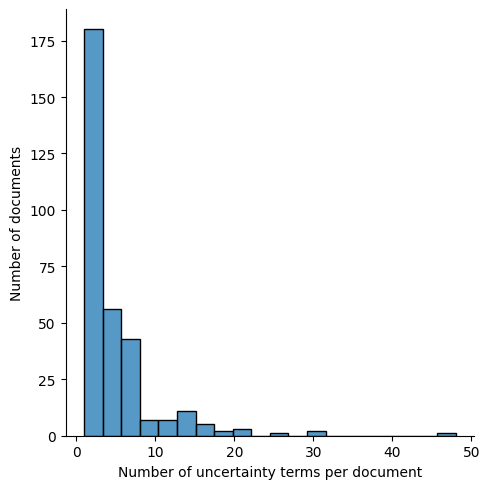

In [5]:
# plotting the doc uncertainty term count per doc 
plt.figure()
sns.displot(df["Uncertainty"], bins = 20)
plt.xlabel("Number of uncertainty terms per document")
plt.ylabel("Number of documents")
plt.show()

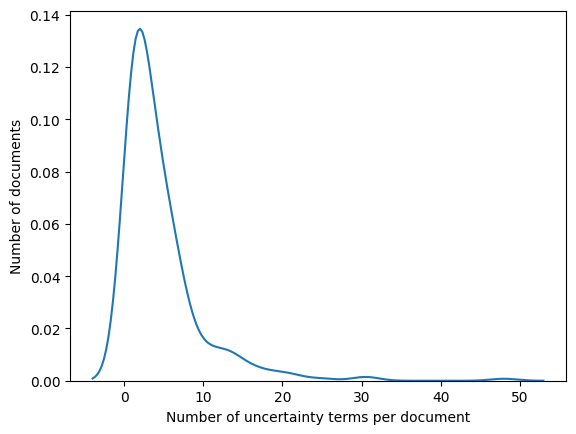

In [6]:
plt.figure()
sns.kdeplot(df["Uncertainty"])
plt.xlabel("Number of uncertainty terms per document")
plt.ylabel("Number of documents")
plt.show()

3. Plots unique words per doc

In [40]:
import os
import pandas as pd



uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])



def tokenize(file):
    with open(file, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)
    doc = nlp(text)
    return doc
    


def find_uncertainty_term(doc_tok):
    found_terms = set()
    found_terms.update([w.text.lower() for w in doc if w.text.lower() in uncertainty_terms])
    return found_terms


    
doc_u_counts = []
filenames = []
unique_terms = []
total_uc = 0
for file in os.listdir("scraped_a"):
    filepath = os.path.join("scraped_a", file)
    doc = tokenize(filepath)
    found_terms = find_uncertainty_term(doc)

    if found_terms:
        total_uc += 1

        doc_u_counts.append(len(found_terms))
        filenames.append(file)
        unique_terms.append(found_terms)


df = pd.DataFrame(doc_u_counts, index = filenames, columns = ["Unique Uncertainty Terms"] )


In [41]:
counts = df["Unique Uncertainty Terms"].value_counts().sort_index()
counts_sorted = counts.sort_index(ascending = False)
counts_sorted

Unique Uncertainty Terms
9      1
7      1
6      8
5     11
4     27
3     52
2     70
1    148
Name: count, dtype: int64

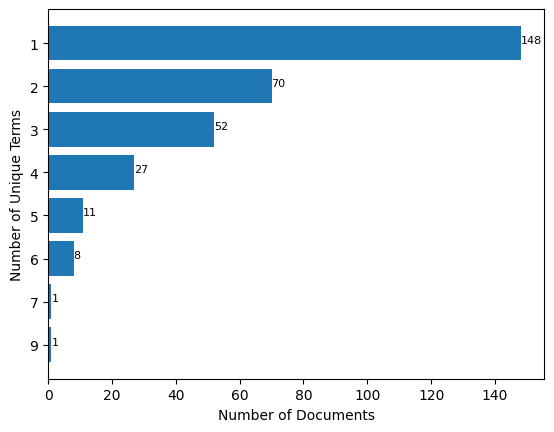

In [44]:
import matplotlib.pyplot as plt
plt.figure()
plt.barh(y = range(len(counts_sorted.index)), width = counts_sorted.values)
plt.yticks(ticks=range(len(counts_sorted)), labels = counts_sorted.index)
for idx, value in enumerate(counts_sorted.values):
    plt.text(value, idx, f"{value}", fontsize = 8)
plt.ylabel("Number of Unique Terms")
plt.xlabel("Number of Documents")
plt.savefig("statcan_unique_dist.png")
plt.show("Unique Term Uncertainty Count")

4. Plots type of term and frequency

In [45]:
from collections import Counter
import os 
import pandas as pd
import spacy
nlp = spacy.load("en_core_web_sm")

uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predicatable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])


def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[6:]
        text = "".join(lines)
        doc = nlp(text)
        return(doc)
    
    
def f_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [w.text.lower() for w in doc_tokens if w.text.lower() in uncertainty_terms]
    return found_terms

u_counts = Counter()

for file in os.listdir("scraped_a"):
    file_path = os.path.join("scraped_a", file)
    doc = tokenize_text(file_path)
    terms = f_uncertainty_terms(doc)
    u_counts.update(terms)

    

In [46]:
u_counts.values()
df = pd.DataFrame(dict(words = u_counts.keys(), freq = u_counts.values()))
df_sorted = df.sort_values("freq", ascending= False)

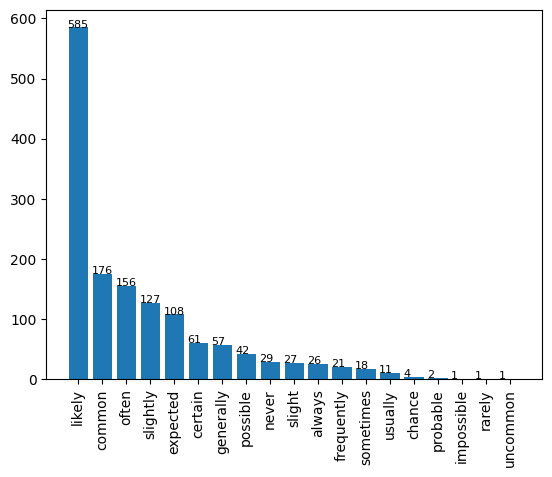

In [48]:
import matplotlib.pyplot as plt
def addlabels(df_sorted):
    for i in range(len(df_sorted)):
        plt.text(i - 0.45, df_sorted.iloc[i]["freq"], str(df_sorted.iloc[i]["freq"]), fontsize = 8)


plt.bar("words" ,"freq",data = df_sorted)
addlabels(df_sorted)
plt.xticks(rotation = 90)
plt.show()

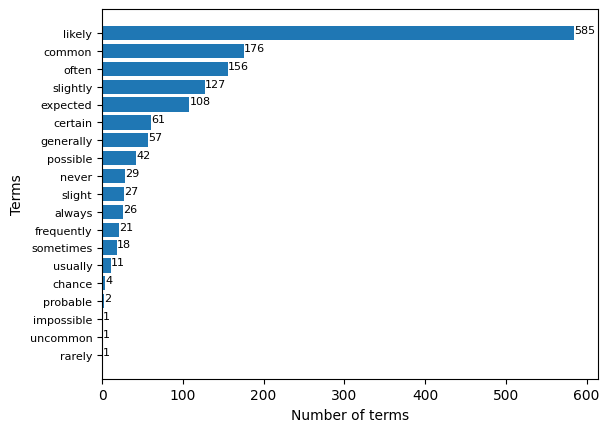

In [49]:
import matplotlib.pyplot as plt
def addlabels(df_sorted):
    for i in range(len(df_sorted)):
        plt.text(df_sorted.iloc[i]["freq"] + 0.2,i, str(df_sorted.iloc[i]["freq"]), fontsize = 8)


df_sorted = df_sorted.sort_values(by = "freq", ascending=True)
plt.barh(df_sorted["words"] ,df_sorted["freq"])
addlabels(df_sorted)
plt.xlabel("Number of terms")
plt.ylabel("Terms")
plt.yticks(fontsize = 8)
plt.show()

5. Looks at context around uncertainty terms (single words) found

In [10]:
import os
import spacy
from nltk.util import ngrams


nlp = spacy.load("en_core_web_sm")

excluded_words = ["$", "\n",
                    "\xa0","toll-free1-800-263-1136;514-283-8300;infostats@statcan.gc.ca", "article",
                    "statcan.mediahotline-ligneinfomedias.statcan@statcan.gc.ca"]


uncertainty_terms = set([
    "always", "certain", "chance", "common", "doubtful", "expected","frequently","generally", "likely", 
    "impossible","never","inconclusive","often",
    "possible", "predictable", "probable","rarely", "seldom", "slightly", "slight", "sometimes", 
    "uncertain", "uncommon","usually", "unlikely"
])


# tokenization fnc
excluded_tokens = set()
def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[2:]
        
    text = "".join(lines)

    # create doc with tokens
    doc = nlp(text)
    return doc


# uncertainty fnc
def find_uncertainty_terms(doc_tokens):
    found_terms = []
    found_terms += [word.text.lower() for word in doc_tokens if word.text.lower() in uncertainty_terms]
    return found_terms

# term context fnc
def find_word_context(doc_tokens, word, window=10):
    term_contexts = []
    
    for i, token in enumerate(doc_tokens):
        if token.text.lower() == word.lower():
            start = max(0, i - window)
            end = min(len(doc_tokens), i + window + 1)
            term_contexts.append(doc_tokens[start:end])

    return term_contexts

# Directory with files
directory = "scraped_a"  

# Directory where files with word context will be done
output_directory = "term_contexts"
output_file_path = os.path.join(output_directory, "likely.txt")


with open(output_file_path, "w") as out_file:
    for file in os.listdir(directory):
        file_path = os.path.join(directory, file)
        doc = tokenize_text(file_path)

        
        word_contexts = find_word_context(doc, "likely")
        
        if word_contexts:
            out_file.write(f"Title : {file}\n")

            for ctx in word_contexts:
                out_file.write("Context:" + " ".join([token.text for token in ctx]) + "\n")
            out_file.write("\n")


6. Implementation of Bigrams

In [2]:
import spacy 
from spacy.matcher import PhraseMatcher

In [ ]:
from collections import Counter

nlp = spacy.load("en_core_web_sm")

# create bigrams -> turn into docs so phrase matcher can work with it 
matcher = PhraseMatcher(nlp.vocab)

bigrams = ["almost always", "almost certain", "almost impossible", "almost never", 
           "high chance", "low chance", "very likely", "very often", "very unlikely", "not always"]

patterns = [nlp(bigram) for bigram in bigrams]

matcher.add("BIGRAMS", patterns)

def tokenize_text(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()[7:]
        text = "".join(lines)
        doc = nlp(text)
        return(doc)


bigram_count = Counter()
for file in os.listdir("scraped_a"):
    file_path = os.path.join("scraped_a", file)
    doc = tokenize_text(file_path)
    matches = matcher(doc)   

    for match_id, start, end in matches:
        matched_span = doc[start:end]
        bigram_count[matched_span.text] += 1

b_counts = bigram_count.most_common()
      


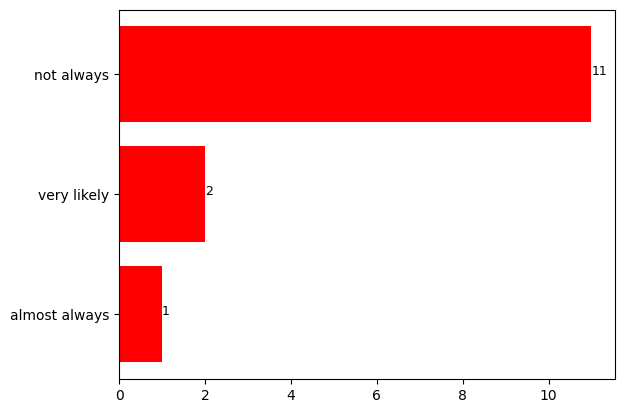

In [8]:
import matplotlib.pyplot as plt
b_counts.sort(key = lambda x:x[1], reverse = False)  
bigrams , counts = zip(*b_counts)
plt.figure()
bars = plt.barh(bigrams, counts, color = "red")
for bar in bars:
    x_value = bar.get_width()
    plt.text(x_value, bar.get_y() + bar.get_height()/2 , str(x_value), fontsize = 9)
